In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import mnist_loader
training_data, validation_data, test_data = mnist_loader.load_data_wrapper()

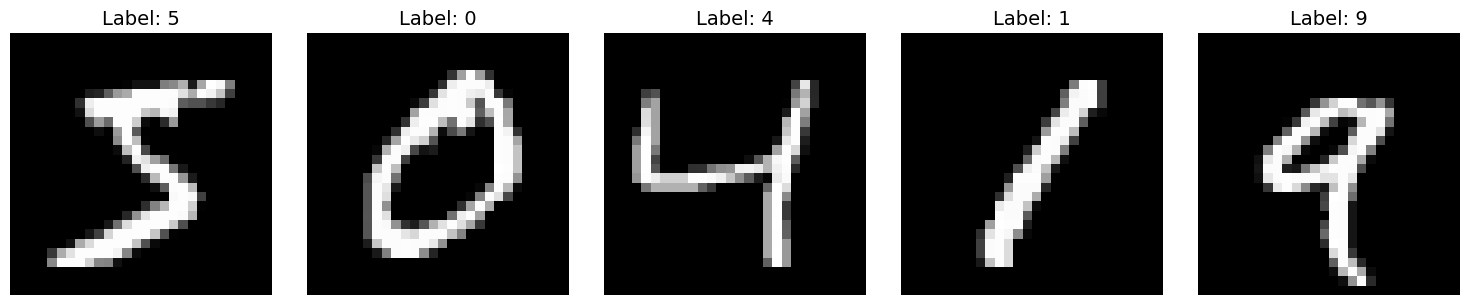

In [3]:
num_images = 5
fig, axes = plt.subplots(1, num_images, figsize=(15, 3))

for i in range(num_images):
    # Extract the image vector (x) and label vector (y) from the tuple
    x, y = training_data[i]
    
    # Reshape the (784, 1) column vector back into a 28x28 pixel grid
    image = np.reshape(x, (28, 28))
    
    # The training label 'y' is a 10x1 one-hot vector (e.g., [0,0,1,0,...]). 
    # np.argmax finds the position of the '1.0', giving us the actual digit.
    label = np.argmax(y)
    
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f"Label: {label}", fontsize=14)
    axes[i].axis('off') # Hide the axis ticks for a cleaner look

plt.tight_layout()
plt.show()

In [4]:
'''
Sizes: the number of neurons in each layer of the network. 
For example, if we want a network with 3 layers, where the input layer has 784 neurons (for MNIST),
the hidden layer has 128 neurons, and the output layer has 10 neurons (for 10 classes), we would set sizes = [784, 128, 10].



'''

class SimpleNN(object):
    def __init__ (self,sizes):
        self.num_layers = len(sizes)
        self.biases = [np.random.randn(y,1) for y in sizes[1:]]
        self.weights = [np.random.randn(y,x) for x,y in zip(sizes[:-1],sizes[1:])]

    def feedforward(self,a):
        for b,w in zip(self.biases,self.weights):
            a = sigmoid(np.dot(w,a)+b)
        return a

    def SGD(self,training_data,epochs,mini_batch_size,learning_rate,validation_data= None
    ):
        training_loss_history = []
        validation_acc_history = []

        if validation_data:
            n_val = len(validation_data)
        n = len(training_data)


        for j in range(epochs):
            np.random.shuffle(training_data)
            mini_batches = [training_data[k:k+mini_batch_size] for k in range(0,n,mini_batch_size)]
            for mini_batch in mini_batches:
                self.update_mini_batch(mini_batch,learning_rate)

            epoch_loss = self.calculate_loss(training_data)
            training_loss_history.append(epoch_loss)

            if validation_data:
                correct_predictions = self.evaluate(validation_data)
                accuracy = correct_predictions / n_val
                validation_acc_history.append(accuracy)
                print(f"Epoch {j}: Validation Accuracy {accuracy} / {n_val}")
            else:
                print(f"Epoch {j} complete | Training Loss: {epoch_loss:.4f}")

    def update_mini_batch(self,mini_batch,learning_rate):
        nabla_b = [np.zeros(b.shape) for b in self.biases]
        nabla_w = [np.zeros(w.shape) for w in self.weights]
        for x,y in mini_batch:
            delta_nabla_b, delta_nabla_w = self.backprop(x,y)
            nabla_b = [nb+dnb for nb,dnb in zip(nabla_b,delta_nabla_b)]
            nabla_w = [nw+dnw for nw,dnw in zip(nabla_w,delta_nabla_w)]
        self.weights = [w-(learning_rate/len(mini_batch))*nw for w,nw in zip(self.weights,nabla_w)]
        self.biases = [b-(learning_rate/len(mini_batch))*nb for b,nb in zip(self.biases,nabla_b)]   
    def backprop(self,x,y):
        nabla_b = [np.zeros(b.shape) for b in self.biases]
        nabla_w = [np.zeros(w.shape) for w in self.weights]
        # feedforward
        activation = x
        activations = [x] # list to store all the activations, layer by layer
        zs = [] # list to store all the z vectors, layer by layer
        for b,w in zip(self.biases,self.weights):
            z = np.dot(w,activation)+b
            zs.append(z)
            activation = sigmoid(z)
            activations.append(activation)
        # backward pass
        delta = self.cost_derivative(activations[-1],y) * sigmoid_prime(zs[-1])
        nabla_b[-1] = delta
        nabla_w[-1] = np.dot(delta,activations[-2].transpose())
        for l in range(2,self.num_layers):
            z = zs[-l]
            sp = sigmoid_prime(z)
            delta = np.dot(self.weights[-l+1].transpose(),delta) * sp
            nabla_b[-l] = delta
            nabla_w[-l] = np.dot(delta,activations[-l-1].transpose())
        return (nabla_b, nabla_w)
    def evaluate(self,test_data):
        test_results = [(np.argmax(self.feedforward(x)),y) for (x,y) in test_data]
        return sum(int(x==y) for (x,y) in test_results)
    def cost_derivative(self,output_activations,y):
        return (output_activations-y)
    
    def calculate_loss(self, data):
        total_loss = 0.0
        for x, y in data:
            output = self.feedforward(x)
            total_loss += np.sum((output - y) ** 2)
        return total_loss / len(data)


def sigmoid(z):
    """The sigmoid function."""
    return 1.0/(1.0+np.exp(-z))

def sigmoid_prime(z):
    """Derivative of the sigmoid function."""
    return sigmoid(z)*(1-sigmoid(z))




In [5]:
import mnist_loader
training_data, validation_data, test_data = mnist_loader.load_data_wrapper()

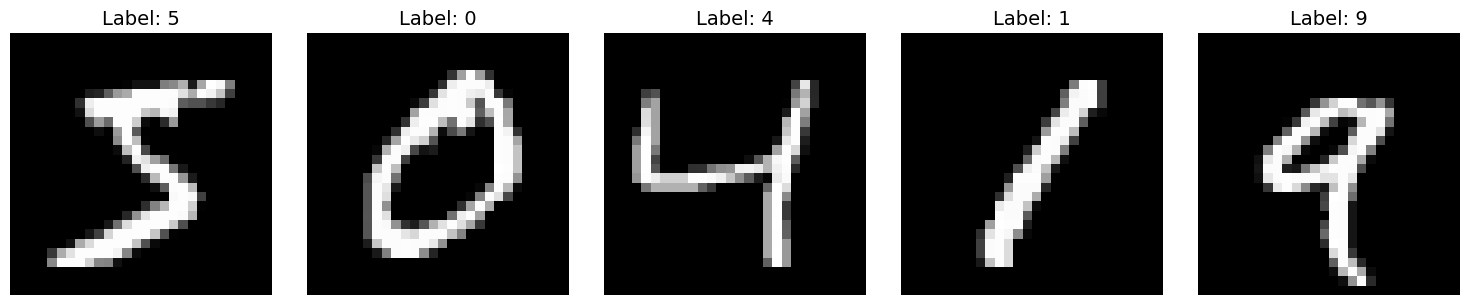

In [6]:
num_images = 5
fig, axes = plt.subplots(1, num_images, figsize=(15, 3))

for i in range(num_images):
    # Extract the image vector (x) and label vector (y) from the tuple
    x, y = training_data[i]
    
    # Reshape the (784, 1) column vector back into a 28x28 pixel grid
    image = np.reshape(x, (28, 28))
    
    # The training label 'y' is a 10x1 one-hot vector (e.g., [0,0,1,0,...]). 
    # np.argmax finds the position of the '1.0', giving us the actual digit.
    label = np.argmax(y)
    
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f"Label: {label}", fontsize=14)
    axes[i].axis('off') # Hide the axis ticks for a cleaner look

plt.tight_layout()
plt.show()

In [7]:
net = SimpleNN([784, 30, 10])

epochs = 30

# We capture the returned histories into variables
train_loss, val_acc = net.SGD(training_data, epochs=epochs, mini_batch_size=10, learning_rate=3.0, validation_data=validation_data)

# Create a figure with two subplots: one for Loss, one for Accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Training Loss
ax1.plot(range(epochs), train_loss, color='red', marker='o', label='Training Loss (MSE)')
ax1.set_title('Training Loss over Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.grid(True)
ax1.legend()

# Plot Validation Accuracy
ax2.plot(range(epochs), val_acc, color='blue', marker='s', label='Validation Accuracy')
ax2.set_title('Validation Accuracy over Epochs')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (Proportion)')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

Epoch 0: Validation Accuracy 0.908 / 10000
Epoch 1: Validation Accuracy 0.9288 / 10000
Epoch 2: Validation Accuracy 0.9353 / 10000
Epoch 3: Validation Accuracy 0.9391 / 10000
Epoch 4: Validation Accuracy 0.9426 / 10000
Epoch 5: Validation Accuracy 0.9423 / 10000
Epoch 6: Validation Accuracy 0.9458 / 10000
Epoch 7: Validation Accuracy 0.9471 / 10000
Epoch 8: Validation Accuracy 0.9468 / 10000
Epoch 9: Validation Accuracy 0.9483 / 10000
Epoch 10: Validation Accuracy 0.9481 / 10000
Epoch 11: Validation Accuracy 0.9494 / 10000
Epoch 12: Validation Accuracy 0.9524 / 10000
Epoch 13: Validation Accuracy 0.9505 / 10000
Epoch 14: Validation Accuracy 0.952 / 10000
Epoch 15: Validation Accuracy 0.9537 / 10000
Epoch 16: Validation Accuracy 0.9517 / 10000
Epoch 17: Validation Accuracy 0.9504 / 10000
Epoch 18: Validation Accuracy 0.9528 / 10000
Epoch 19: Validation Accuracy 0.9519 / 10000
Epoch 20: Validation Accuracy 0.9541 / 10000
Epoch 21: Validation Accuracy 0.9538 / 10000
Epoch 22: Validation A

TypeError: cannot unpack non-iterable NoneType object